In [13]:
import sys
!{sys.executable} -m pip install scikit-learn xgboost

In [14]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

temp_path = 'GLB.Ts+dSST.csv'
co2_path = 'co2_mm_mlo.csv'

df_temp = pd.read_csv(temp_path)
if 'Year' not in df_temp.columns:
    df_temp = pd.read_csv(temp_path, skiprows=1)

mois_str = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_temp = df_temp[['Year'] + mois_str]

df_temp_melt = pd.melt(df_temp, id_vars=['Year'], value_vars=mois_str,
                       var_name='Month_Name', value_name='Temperature_Anomaly')

month_map = {m: i+1 for i, m in enumerate(mois_str)}
df_temp_melt['Month'] = df_temp_melt['Month_Name'].map(month_map)

df_temp_melt['Temperature_Anomaly'] = pd.to_numeric(df_temp_melt['Temperature_Anomaly'].replace('***', np.nan), errors='coerce')

df_temp_melt = df_temp_melt.rename(columns={'Year': 'year', 'Month': 'month'})

df_co2 = pd.read_csv(co2_path, comment='#')
df_co2.columns = df_co2.columns.str.strip().str.lower()

if 'monthly_average' in df_co2.columns:
    df_co2 = df_co2.rename(columns={'monthly_average': 'co2'})
elif 'average' in df_co2.columns:
    df_co2 = df_co2.rename(columns={'average': 'co2'})

df_co2 = df_co2[['year', 'month', 'co2']]

df_climate = pd.merge(df_temp_melt[['year', 'month', 'Temperature_Anomaly']],
                      df_co2, on=['year', 'month'], how='inner')

df_climate = df_climate.dropna().sort_values(by=['year', 'month']).reset_index(drop=True)

df_climate['Date'] = pd.to_datetime(df_climate[['year', 'month']].assign(day=1))
df_climate = df_climate[['Date', 'year', 'month', 'Temperature_Anomaly', 'co2']]

display(df_climate.head())

,Date,year,month,Temperature_Anomaly,co2
0,1958-03-01,1958,3,0.08,315.71
1,1958-04-01,1958,4,0.01,317.45
2,1958-05-01,1958,5,0.06,317.51
3,1958-06-01,1958,6,-0.09,317.27
4,1958-07-01,1958,7,0.05,315.87


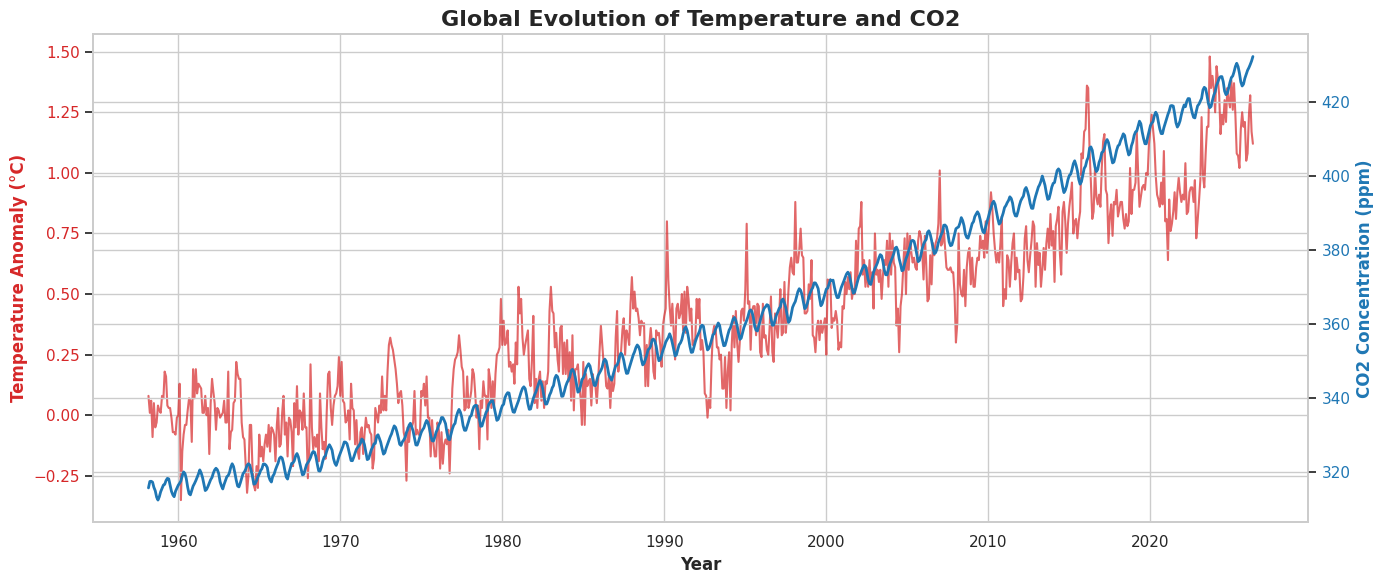

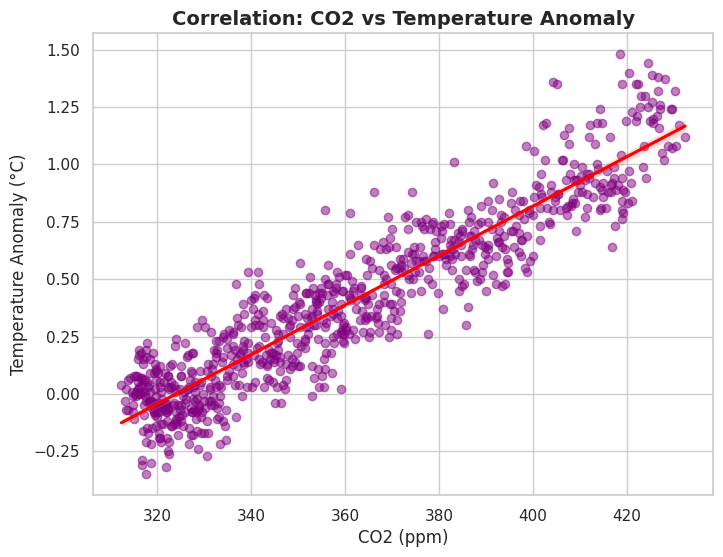

Variance explained by Principal Component 1: 96.47%
Variance explained by Principal Component 2: 3.53%


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = 'tab:red'
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Temperature Anomaly (°C)', color=color1, fontweight='bold')
ax1.plot(df_climate['Date'], df_climate['Temperature_Anomaly'], color=color1, alpha=0.7, label='Temperature')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('CO2 Concentration (ppm)', color=color2, fontweight='bold')
ax2.plot(df_climate['Date'], df_climate['co2'], color=color2, linewidth=2, label='CO2')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Global Evolution of Temperature and CO2', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.regplot(data=df_climate, x='co2', y='Temperature_Anomaly',
            scatter_kws={'alpha':0.5, 'color': 'purple'}, line_kws={'color': 'red'})
plt.title('Correlation: CO2 vs Temperature Anomaly', fontsize=14, fontweight='bold')
plt.xlabel('CO2 (ppm)')
plt.ylabel('Temperature Anomaly (°C)')
plt.show()


features = ['Temperature_Anomaly', 'co2']
X = df_climate[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df_climate['PCA_Indicateur_Climat'] = pca_result[:, 0]

variance_expliquee = pca.explained_variance_ratio_
print(f"Variance explained by Principal Component 1: {variance_expliquee[0]*100:.2f}%")
print(f"Variance explained by Principal Component 2: {variance_expliquee[1]*100:.2f}%")


Decision Tree      | Mean Absolute Error (MAE): 0.286°C | RMSE: 0.344
Random Forest      | Mean Absolute Error (MAE): 0.298°C | RMSE: 0.359
XGBoost            | Mean Absolute Error (MAE): 0.319°C | RMSE: 0.377


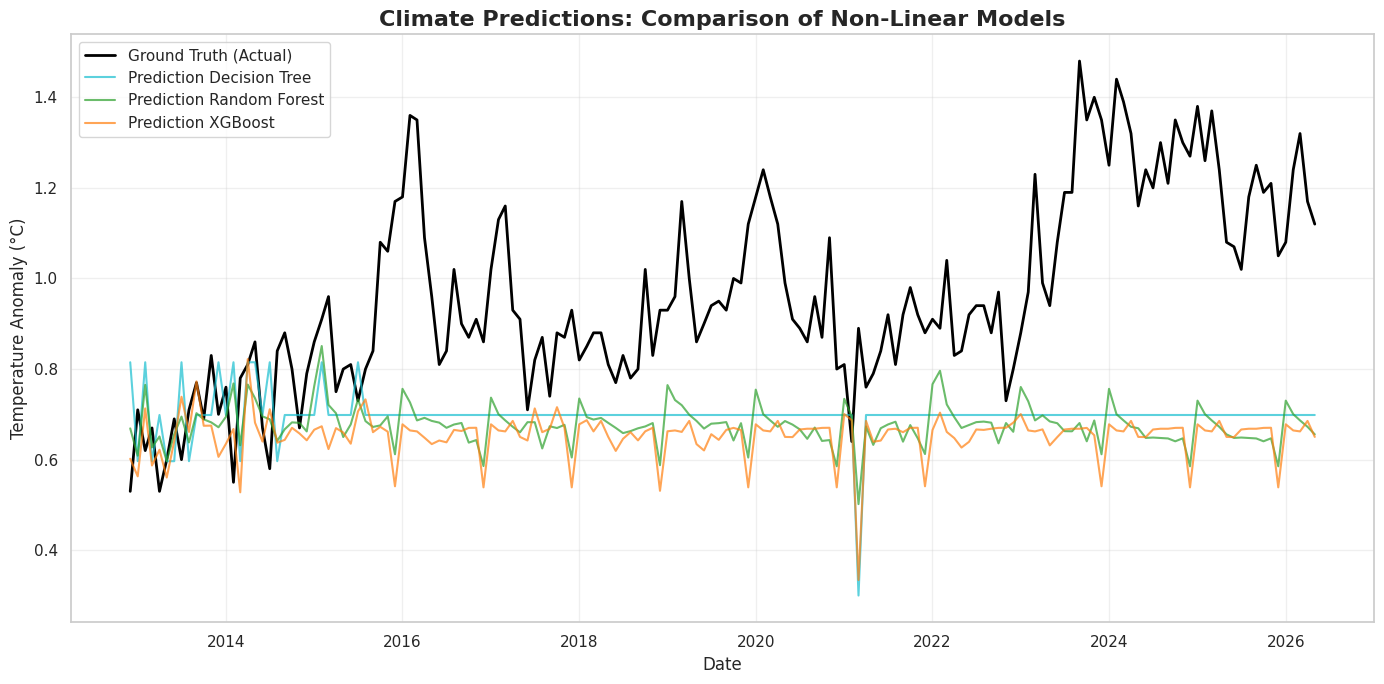

In [16]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

df_ml = df_climate.copy()

df_ml['Temp_Lag_1'] = df_ml['Temperature_Anomaly'].shift(1)
df_ml['Temp_Lag_12'] = df_ml['Temperature_Anomaly'].shift(12)

df_ml = df_ml.dropna().reset_index(drop=True)

features = ['year', 'month', 'co2', 'Temp_Lag_1', 'Temp_Lag_12']
X = df_ml[features]
y = df_ml['Temperature_Anomaly']

split_idx = int(len(df_ml) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df_ml['Date'].iloc[split_idx:]

modeles = {
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

predictions = {}
erreurs = {}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    preds = modele.predict(X_test)
    predictions[nom] = preds

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    erreurs[nom] = {'RMSE': rmse, 'MAE': mae}

for nom, err in erreurs.items():
    print(f"{nom:18s} | Mean Absolute Error (MAE): {err['MAE']:.3f}°C | RMSE: {err['RMSE']:.3f}")

plt.figure(figsize=(14, 7))

plt.plot(dates_test, y_test, label='Ground Truth (Actual)', color='black', linewidth=2)

couleurs = ['tab:cyan', 'tab:green', 'tab:orange']
for (nom, preds), couleur in zip(predictions.items(), couleurs):
    plt.plot(dates_test, preds, label=f'Prediction {nom}', color=couleur, alpha=0.7)

plt.title("Climate Predictions: Comparison of Non-Linear Models", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
import sys
!{sys.executable} -m pip install tensorflow

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Input, Layer, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler

print("1. Preparing data for Deep Learning...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

X_train_gnn = X_train_cnn
X_test_gnn = X_test_cnn

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

print("2. Training Balanced Macro-Trend ANN...")
ann_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),

    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.1),

    Dense(1)
], name="ANN_Model_Balanced_Trend")

ann_model.compile(optimizer='adam', loss='mse')
history_ann = ann_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    verbose=0,
    validation_split=0.1,
    callbacks=[early_stopping]
)
preds_ann = ann_model.predict(X_test_scaled, verbose=0).flatten()


print("3. Training Fixed 1D CNN (No Batch Normalization)...")
cnn_model = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),
    Conv1D(filters=32, kernel_size=2, activation='relu', kernel_regularizer=l2(0.001)),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1)
], name="CNN_Model_Fixed")

cnn_model.compile(optimizer='adam', loss='mse')
history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=16,
    verbose=0,
    validation_split=0.1,
    callbacks=[early_stopping]
)
preds_cnn = cnn_model.predict(X_test_cnn, verbose=0).flatten()


print("4. Training GNN (Graph Neural Network)...")
class SimpleGCN(Layer):
    def __init__(self, units, **kwargs):
        super(SimpleGCN, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], self.units), initializer='glorot_uniform', trainable=True)
        self.A = self.add_weight(shape=(input_shape[1], input_shape[1]), initializer='ones', trainable=True)

    def call(self, inputs):
        h = tf.matmul(inputs, self.W)
        output = tf.matmul(self.A, h)
        return tf.nn.relu(output)

gnn_input = Input(shape=(X_train_gnn.shape[1], 1))
x = SimpleGCN(16)(gnn_input)
x = Flatten()(x)
x = Dense(16, activation='relu')(x)
gnn_output = Dense(1)(x)

gnn_model = Model(inputs=gnn_input, outputs=gnn_output, name="GNN_Model")
gnn_model.compile(optimizer='adam', loss='mse')
history_gnn = gnn_model.fit(
    X_train_gnn, y_train,
    epochs=100,
    batch_size=16,
    verbose=0,
    validation_split=0.1,
    callbacks=[early_stopping]
)
preds_gnn = gnn_model.predict(X_test_gnn, verbose=0).flatten()

print("All models re-trained. The updated ANN should follow a stable, smooth directional trend line!")

1. Preparing data for Deep Learning...
2. Training Balanced Macro-Trend ANN...
3. Training Fixed 1D CNN (No Batch Normalization)...
4. Training GNN (Graph Neural Network)...
All models re-trained. The updated ANN should follow a stable, smooth directional trend line!


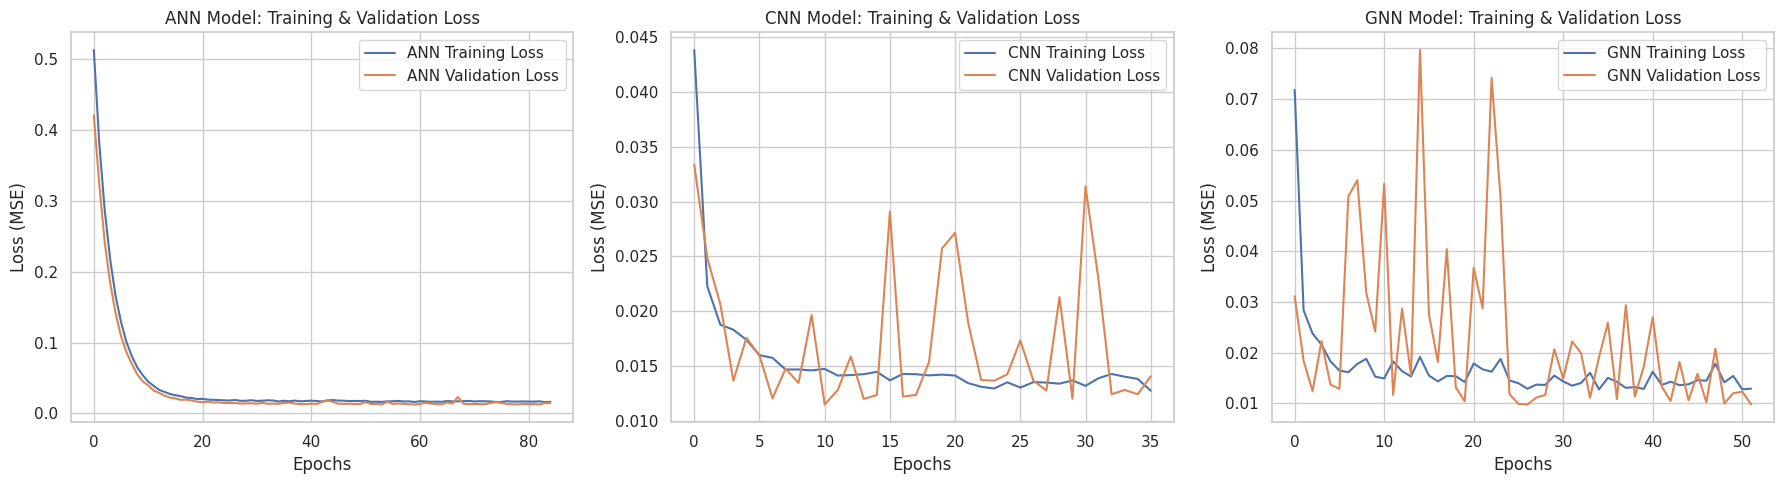

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history_ann.history['loss'], label='ANN Training Loss')
plt.plot(history_ann.history['val_loss'], label='ANN Validation Loss')
plt.title('ANN Model: Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history_cnn.history['loss'], label='CNN Training Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Validation Loss')
plt.title('CNN Model: Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(history_gnn.history['loss'], label='GNN Training Loss')
plt.plot(history_gnn.history['val_loss'], label='GNN Validation Loss')
plt.title('GNN Model: Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

DL - ANN (Dense)     | RMSE: 0.2306 | R²: -0.2031
DL - CNN 1D          | RMSE: 0.1505 | R²: 0.4874
DL - GNN (Graph)     | RMSE: 0.1339 | R²: 0.5945
ML - Decision Tree   | RMSE: 0.3435 | R²: -1.6695
ML - Random Forest   | RMSE: 0.3591 | R²: -1.9162
ML - XGBoost         | RMSE: 0.3773 | R²: -2.2194


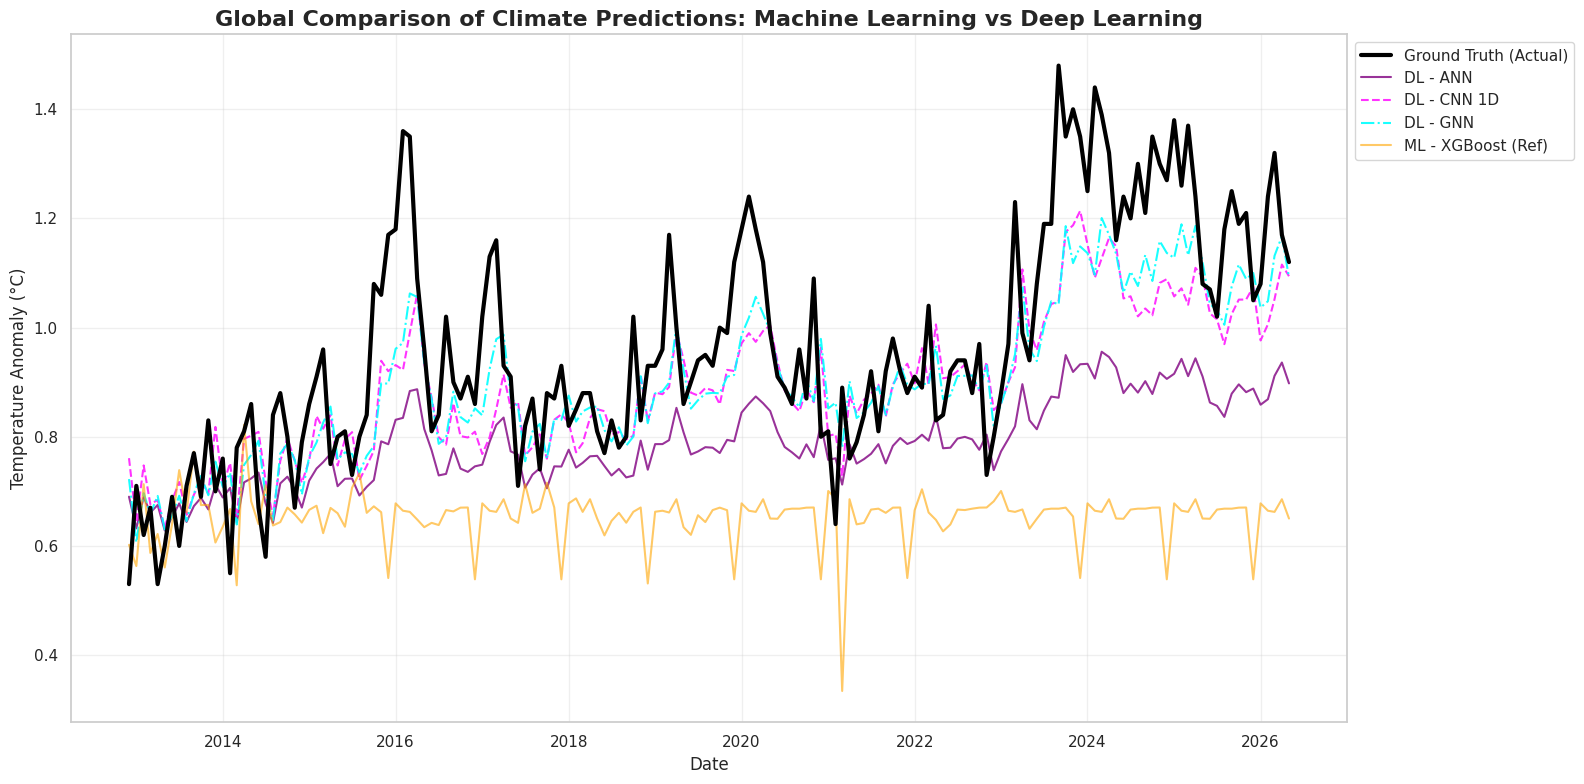

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

toutes_les_preds = {
    'DL - ANN (Dense)': preds_ann,
    'DL - CNN 1D': preds_cnn,
    'DL - GNN (Graph)': preds_gnn
}

if 'predictions' in locals():
    for nom, preds in predictions.items():
        toutes_les_preds[f'ML - {nom}'] = preds

metriques = {}
for nom, preds in toutes_les_preds.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    metriques[nom] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{nom:20s} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

plt.figure(figsize=(16, 8))

plt.plot(dates_test, y_test, label='Ground Truth (Actual)', color='black', linewidth=3, zorder=5)

plt.plot(dates_test, preds_ann, label='DL - ANN', color='purple', alpha=0.8, linestyle='-')
plt.plot(dates_test, preds_cnn, label='DL - CNN 1D', color='magenta', alpha=0.8, linestyle='--')
plt.plot(dates_test, preds_gnn, label='DL - GNN', color='cyan', alpha=0.9, linestyle='-.')

if 'predictions' in locals() and 'XGBoost' in predictions:
    plt.plot(dates_test, predictions['XGBoost'], label='ML - XGBoost (Ref)', color='orange', alpha=0.6)

plt.title("Global Comparison of Climate Predictions: Machine Learning vs Deep Learning", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

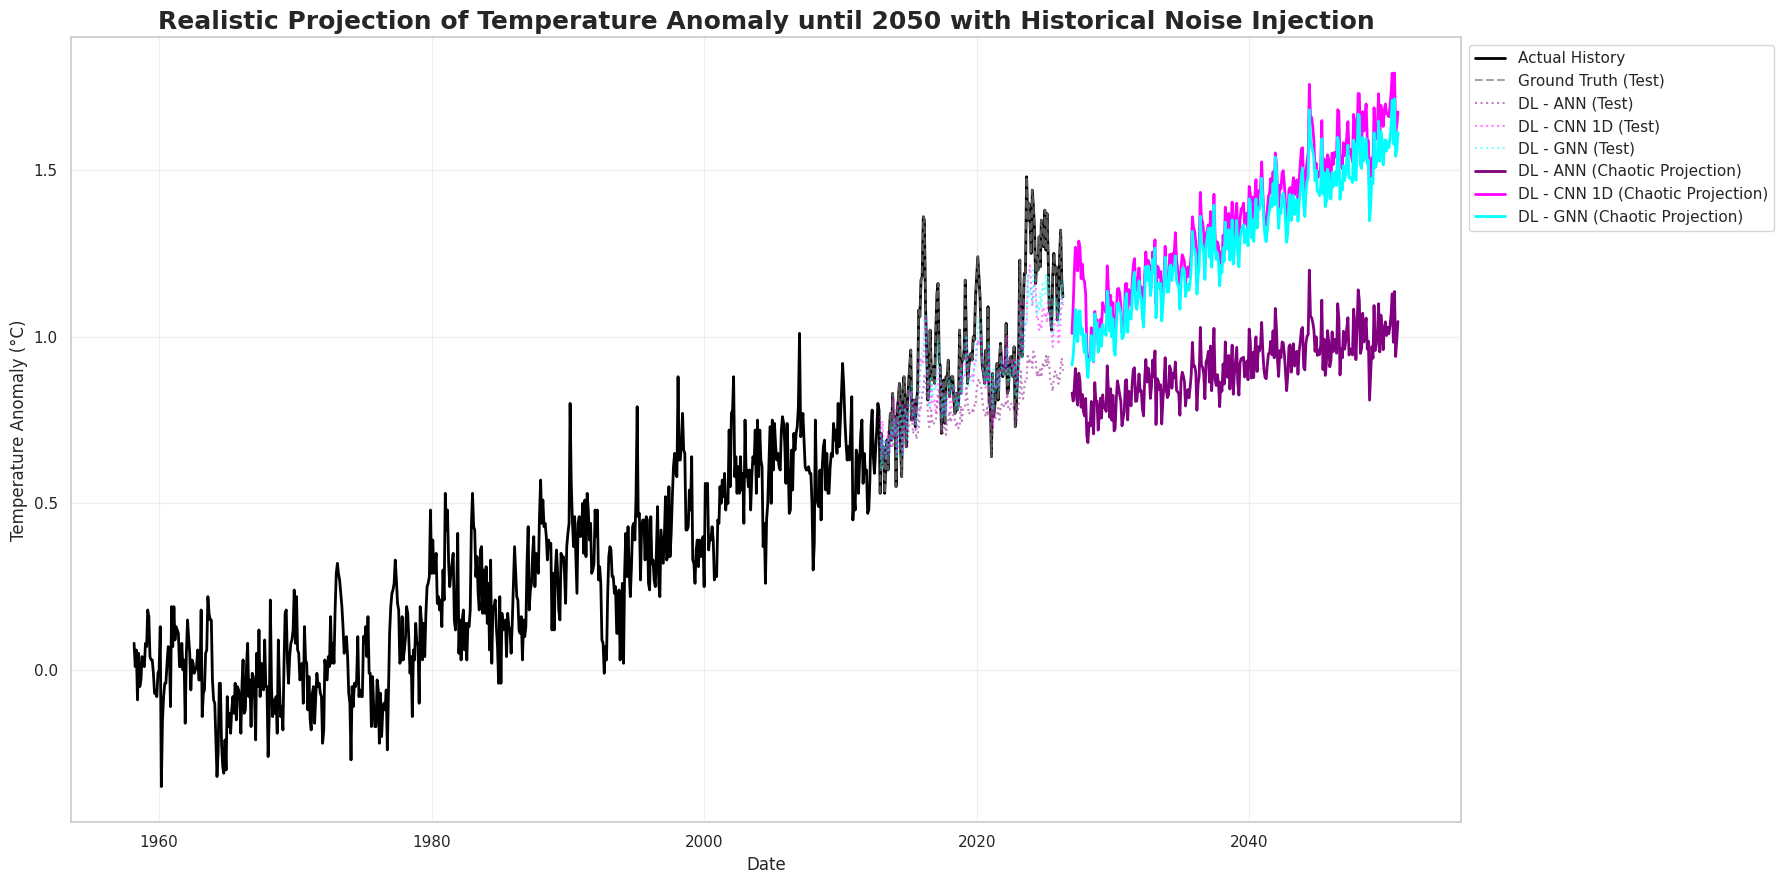

In [21]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X_co2_train = df_climate[['year']]
X_co2_train['year_sq'] = X_co2_train['year']**2
y_co2_train = df_climate['co2']

co2_trend_model = LinearRegression()
co2_trend_model.fit(X_co2_train, y_co2_train)

future_years = pd.DataFrame({
    'year': np.repeat(np.arange(df_climate['year'].max() + 1, 2051), 12),
    'month': list(range(1, 13)) * (2051 - (df_climate['year'].max() + 1))
})
remaining_months = pd.DataFrame({
    'year': df_climate['year'].max(),
    'month': range(df_climate['month'].max() + 1, 13)
})
if not remaining_months.empty:
    future_years = pd.concat([remaining_months, future_years], ignore_index=True)

df_future = future_years.copy()
df_future['Date'] = pd.to_datetime(df_future[['year', 'month']].assign(day=1))

X_co2_future = df_future[['year']]
X_co2_future['year_sq'] = X_co2_future['year']**2
df_future['co2'] = co2_trend_model.predict(X_co2_future)

X_future_models = df_future[['year', 'month', 'co2']].copy()

historical_noise_std = df_climate['Temperature_Anomaly'].std() * 0.15

def predict_future_with_chaos(model, X_initial, y_initial, df_future_features, scaler_fitted, model_type='ml', noise_scale=0.0):
    X_current = X_initial.copy()
    y_current = y_initial.copy()
    all_predictions = []

    last_temp_anomaly = y_current.iloc[-1]
    last_temp_lag_1 = X_current['Temp_Lag_1'].iloc[-1]
    last_temp_lag_12 = X_current['Temp_Lag_12'].iloc[-1]

    np.random.seed(42)

    for i in range(len(df_future_features)):
        current_year = df_future_features['year'].iloc[i]
        current_month = df_future_features['month'].iloc[i]
        current_co2 = df_future_features['co2'].iloc[i]

        if i == 0:
            features_row = pd.DataFrame([[current_year, current_month, current_co2, last_temp_anomaly, last_temp_lag_12]],
                                        columns=['year', 'month', 'co2', 'Temp_Lag_1', 'Temp_Lag_12'])
        else:
            features_row = pd.DataFrame([[current_year, current_month, current_co2, all_predictions[-1], previous_year_lag]],
                                        columns=['year', 'month', 'co2', 'Temp_Lag_1', 'Temp_Lag_12'])

        scaled_features_row = scaler_fitted.transform(features_row)

        if model_type == 'cnn' or model_type == 'gnn':
            scaled_features_row = scaled_features_row.reshape(1, scaled_features_row.shape[1], 1)

        base_prediction = model.predict(scaled_features_row, verbose=0).flatten()[0]

        random_variation = np.random.normal(0, noise_scale) if noise_scale > 0 else 0
        final_prediction = base_prediction + random_variation

        all_predictions.append(final_prediction)

        if len(all_predictions) >= 12:
            previous_year_lag = all_predictions[len(all_predictions) - 12]
        else:
            previous_year_lag = X_current['Temp_Lag_12'].iloc[-(12-len(all_predictions))]
            if len(all_predictions) == 1:
                previous_year_lag = last_temp_lag_12

    return np.array(all_predictions)

future_preds_ann = predict_future_with_chaos(ann_model, X_train, y_train, X_future_models, scaler, model_type='ann', noise_scale=historical_noise_std)
future_preds_cnn = predict_future_with_chaos(cnn_model, X_train, y_train, X_future_models, scaler, model_type='cnn', noise_scale=historical_noise_std)
future_preds_gnn = predict_future_with_chaos(gnn_model, X_train, y_train, X_future_models, scaler, model_type='gnn', noise_scale=historical_noise_std)

df_future['DL - ANN'] = future_preds_ann
df_future['DL - CNN 1D'] = future_preds_cnn
df_future['DL - GNN'] = future_preds_gnn

plt.figure(figsize=(18, 9))
plt.plot(df_climate['Date'], df_climate['Temperature_Anomaly'], label='Actual History', color='black', linewidth=2)
plt.plot(dates_test, y_test, label='Ground Truth (Test)', color='gray', linestyle='--', alpha=0.7)

plt.plot(dates_test, preds_ann, label='DL - ANN (Test)', color='purple', alpha=0.5, linestyle=':')
plt.plot(dates_test, preds_cnn, label='DL - CNN 1D (Test)', color='magenta', alpha=0.5, linestyle=':')
plt.plot(dates_test, preds_gnn, label='DL - GNN (Test)', color='cyan', alpha=0.5, linestyle=':')

plt.plot(df_future['Date'], df_future['DL - ANN'], label='DL - ANN (Chaotic Projection)', color='purple', linewidth=2, linestyle='-')
plt.plot(df_future['Date'], df_future['DL - CNN 1D'], label='DL - CNN 1D (Chaotic Projection)', color='magenta', linewidth=2, linestyle='-')
plt.plot(df_future['Date'], df_future['DL - GNN'], label='DL - GNN (Chaotic Projection)', color='cyan', linewidth=2, linestyle='-')

plt.title('Realistic Projection of Temperature Anomaly until 2050 with Historical Noise Injection', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature Anomaly (°C)', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()